In [1]:
!pip install pandas numpy matplotlib seaborn plotly


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")


In [ ]:
df = pd.read_csv("APL_Logistics.csv", encoding="latin1")
df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [5]:
df.shape
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107607,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,6691.379495,20.664741,0.101668,141.232547,0.120647,2.127638,203.772092,183.107607,21.974989,141.232547
std,1.623722,1.374449,104.433526,120.043668,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,4162.918106,21.800901,0.070415,139.732489,0.466796,1.453451,132.273075,120.043668,104.433526,139.732489
min,0.000000,0.000000,-4274.980000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.980000,9.990000
25%,2.000000,2.000000,7.000000,104.380000,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,3258.500000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980000,104.380000,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990000,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,6457.000000,14.000000,0.100000,59.990000,0.270000,1.000000,199.920000,163.990000,31.520000,59.990000
75%,5.000000,4.000000,64.800000,247.400000,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,9779.000000,29.990000,0.160000,199.990000,0.360000,3.000000,299.950000,247.400000,64.800000,199.990000
max,6.000000,4.000000,911.800000,1939.990000,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,20757.000000,500.000000,0.250000,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1999.990000


In [6]:
df.columns = df.columns.str.strip()

df.columns


Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Segment', 'Customer State', 'Customer Street',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'Shipping Mode'],
      dtype='object')

In [29]:
important_columns = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Delivery Status",
    "Late_delivery_risk",
    "Shipping Mode",
    "Order Region",
    "Order Country",
    "Market",
    "Customer Segment",
    "Sales",
    "Benefit per order",
    "Order Profit Per Order"
]

df_analysis = df[important_columns].copy()

df_analysis.head()


,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Shipping Mode,Order Region,Order Country,Market,Customer Segment,Sales,Benefit per order,Order Profit Per Order
0,6,4,Late delivery,1,Standard Class,South Asia,India,Pacific Asia,Consumer,499.95,159.69,159.69
1,4,4,Shipping on time,0,Standard Class,Central America,Honduras,LATAM,Consumer,199.95,48.71,48.71
2,4,4,Shipping on time,0,Standard Class,Central America,Honduras,LATAM,Consumer,199.99,87.36,87.36
3,6,4,Late delivery,1,Standard Class,East of USA,Estados Unidos,USCA,Consumer,199.99,-41.89,-41.89
4,6,4,Late delivery,1,Standard Class,East of USA,Estados Unidos,USCA,Consumer,50.00,10.00,10.00


In [30]:
df_analysis.isnull().sum()


Days for shipping (real)         0
Days for shipment (scheduled)    0
Delivery Status                  0
Late_delivery_risk               0
Shipping Mode                    0
Order Region                     0
Order Country                    0
Market                           0
Customer Segment                 0
Sales                            0
Benefit per order                0
Order Profit Per Order           0
dtype: int64

In [31]:
df_analysis = df_analysis.dropna()

df_analysis.shape


(180519, 12)

In [33]:
numeric_cols = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Late_delivery_risk",
    "Sales",
    "Benefit per order",
    "Order Profit Per Order"
]

for col in numeric_cols:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors="coerce")

df_analysis = df_analysis.dropna()
df_analysis.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Days for shipping (real)       180519 non-null  int64  
 1   Days for shipment (scheduled)  180519 non-null  int64  
 2   Delivery Status                180519 non-null  object 
 3   Late_delivery_risk             180519 non-null  int64  
 4   Shipping Mode                  180519 non-null  object 
 5   Order Region                   180519 non-null  object 
 6   Order Country                  180519 non-null  object 
 7   Market                         180519 non-null  object 
 8   Customer Segment               180519 non-null  object 
 9   Sales                          180519 non-null  float64
 10  Benefit per order              180519 non-null  float64
 11  Order Profit Per Order         180519 non-null  float64
dtypes: float64(3), int64(3), objec

In [11]:
df_analysis["Delivery Delay Gap"] = (
    df_analysis["Days for shipping (real)"] 
    - df_analysis["Days for shipment (scheduled)"]
)

df_analysis[[
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Delivery Delay Gap"
]].head()


,Days for shipping (real),Days for shipment (scheduled),Delivery Delay Gap
0,6,4,2
1,4,4,0
2,4,4,0
3,6,4,2
4,6,4,2


In [12]:
def classify_delivery(gap):
    if gap < 0:
        return "Early"
    elif gap == 0:
        return "On-time"
    else:
        return "Delayed"

df_analysis["Delivery Classification"] = df_analysis["Delivery Delay Gap"].apply(classify_delivery)

df_analysis["Delivery Classification"].value_counts()


Delivery Classification
Delayed    103400
Early       43366
On-time     33753
Name: count, dtype: int64

In [13]:
total_orders = len(df_analysis)

on_time_orders = len(df_analysis[df_analysis["Delivery Classification"].isin(["On-time", "Early"])])

delayed_orders = len(df_analysis[df_analysis["Delivery Classification"] == "Delayed"])

on_time_delivery_rate = (on_time_orders / total_orders) * 100

average_delay = df_analysis["Delivery Delay Gap"].mean()

late_delivery_risk_ratio = df_analysis["Late_delivery_risk"].mean() * 100

print("Total Orders:", total_orders)
print("On-Time Delivery Rate (%):", round(on_time_delivery_rate, 2))
print("Delayed Orders:", delayed_orders)
print("Average Delivery Delay Gap:", round(average_delay, 2))
print("Late Delivery Risk Ratio (%):", round(late_delivery_risk_ratio, 2))


Total Orders: 180519
On-Time Delivery Rate (%): 42.72
Delayed Orders: 103400
Average Delivery Delay Gap: 0.57
Late Delivery Risk Ratio (%): 54.83


C:\Users\War Machine\AppData\Local\Temp\ipykernel_11524\3740566004.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


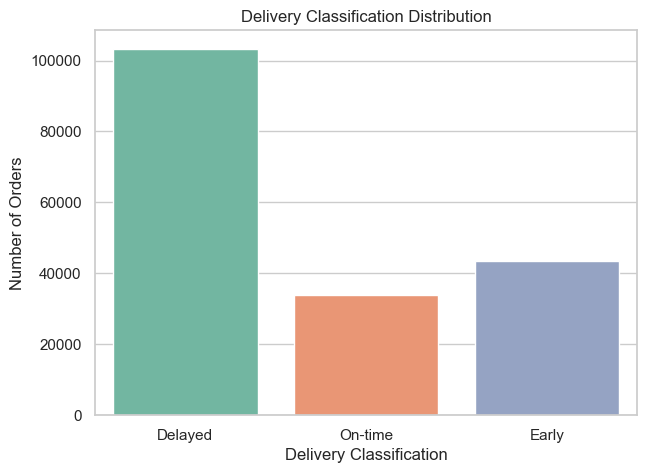

In [14]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_analysis,
    x="Delivery Classification",
    palette="Set2"
)

plt.title("Delivery Classification Distribution")
plt.xlabel("Delivery Classification")
plt.ylabel("Number of Orders")
plt.show()


C:\Users\War Machine\AppData\Local\Temp\ipykernel_11524\900856254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


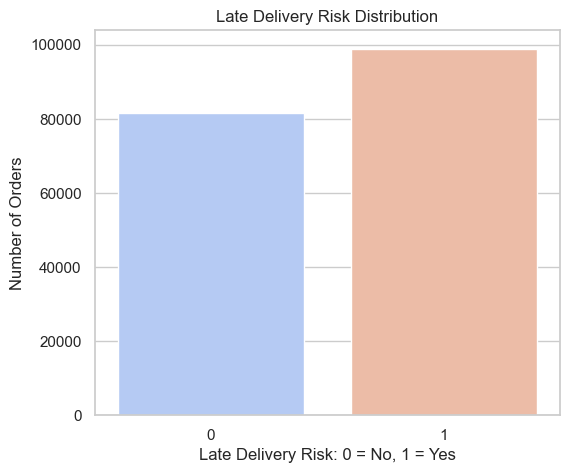

In [15]:
plt.figure(figsize=(6, 5))
sns.countplot(
    data=df_analysis,
    x="Late_delivery_risk",
    palette="coolwarm"
)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk: 0 = No, 1 = Yes")
plt.ylabel("Number of Orders")
plt.show()


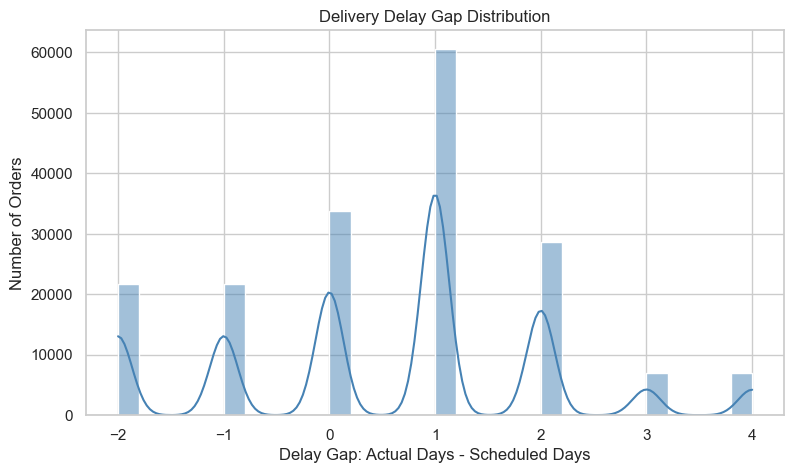

In [16]:
plt.figure(figsize=(9, 5))
sns.histplot(
    df_analysis["Delivery Delay Gap"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Delivery Delay Gap Distribution")
plt.xlabel("Delay Gap: Actual Days - Scheduled Days")
plt.ylabel("Number of Orders")
plt.show()


In [17]:
shipping_mode_analysis = df_analysis.groupby("Shipping Mode").agg(
    Total_Orders=("Shipping Mode", "count"),
    Average_Delay_Gap=("Delivery Delay Gap", "mean"),
    Late_Risk_Ratio=("Late_delivery_risk", "mean")
).reset_index()

shipping_mode_analysis["Late_Risk_Ratio"] *= 100

shipping_mode_analysis


,Shipping Mode,Total_Orders,Average_Delay_Gap,Late_Risk_Ratio
0,First Class,27814,1.000000,95.322499
1,Same Day,9737,0.478279,45.743042
2,Second Class,35216,1.990828,76.632781
3,Standard Class,107752,-0.004093,38.071683


C:\Users\War Machine\AppData\Local\Temp\ipykernel_11524\407473765.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


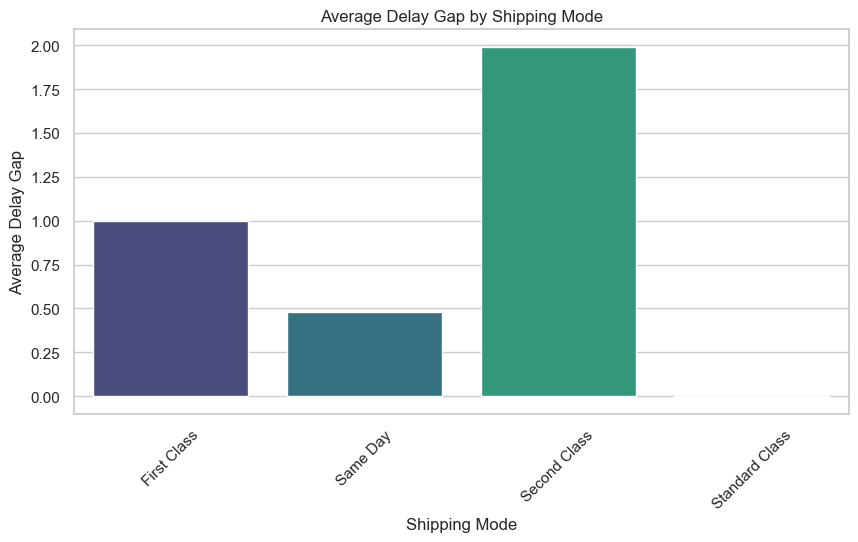

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=shipping_mode_analysis,
    x="Shipping Mode",
    y="Average_Delay_Gap",
    palette="viridis"
)

plt.title("Average Delay Gap by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay Gap")
plt.xticks(rotation=45)
plt.show()


In [19]:
sla_analysis = df_analysis.groupby(["Shipping Mode", "Delivery Classification"]).size().reset_index(name="Count")

sla_analysis


,Shipping Mode,Delivery Classification,Count
0,First Class,Delayed,27814
1,Same Day,Delayed,4657
2,Same Day,On-time,5080
3,Second Class,Delayed,28078
4,Second Class,On-time,7138
5,Standard Class,Delayed,42851
6,Standard Class,Early,43366
7,Standard Class,On-time,21535


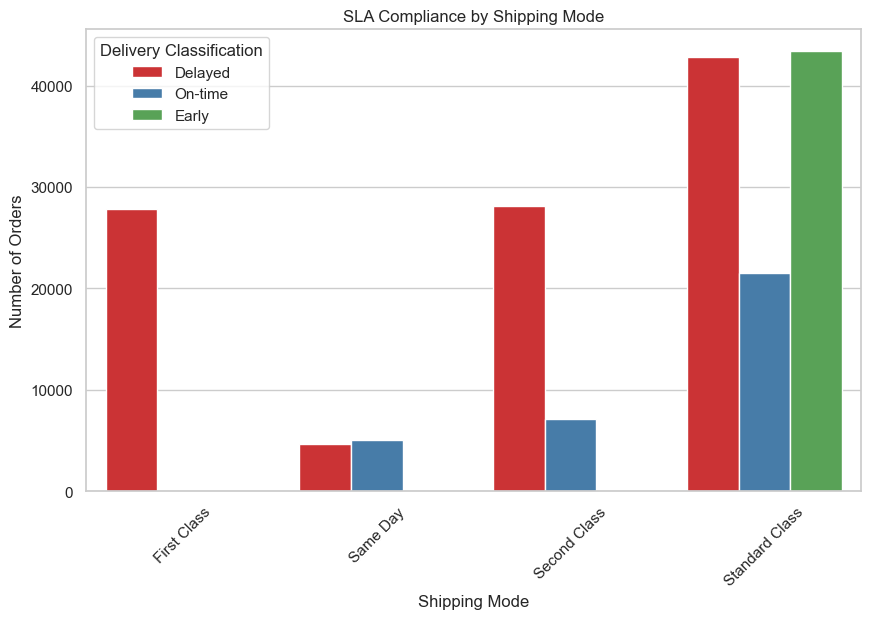

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sla_analysis,
    x="Shipping Mode",
    y="Count",
    hue="Delivery Classification",
    palette="Set1"
)

plt.title("SLA Compliance by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


In [21]:
regional_analysis = df_analysis.groupby("Order Region").agg(
    Total_Orders=("Order Region", "count"),
    Average_Delay_Gap=("Delivery Delay Gap", "mean"),
    Late_Risk_Ratio=("Late_delivery_risk", "mean")
).reset_index()

regional_analysis["Late_Risk_Ratio"] *= 100

regional_analysis = regional_analysis.sort_values(by="Late_Risk_Ratio", ascending=False)

regional_analysis.head(10)


,Order Region,Total_Orders,Average_Delay_Gap,Late_Risk_Ratio
2,Central Africa,1677,0.639833,57.960644
13,South Asia,7731,0.597465,56.266977
5,East Africa,1852,0.570734,55.939525
22,Western Europe,27109,0.597403,55.848611
14,South of USA,4045,0.579975,55.772559
8,Eastern Europe,3920,0.579847,55.663265
6,East of USA,6915,0.584816,55.661605
15,Southeast Asia,9539,0.558235,55.529930
4,Central Asia,553,0.645570,55.334539
20,West Asia,6009,0.569479,55.283741


C:\Users\War Machine\AppData\Local\Temp\ipykernel_11524\1708749624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


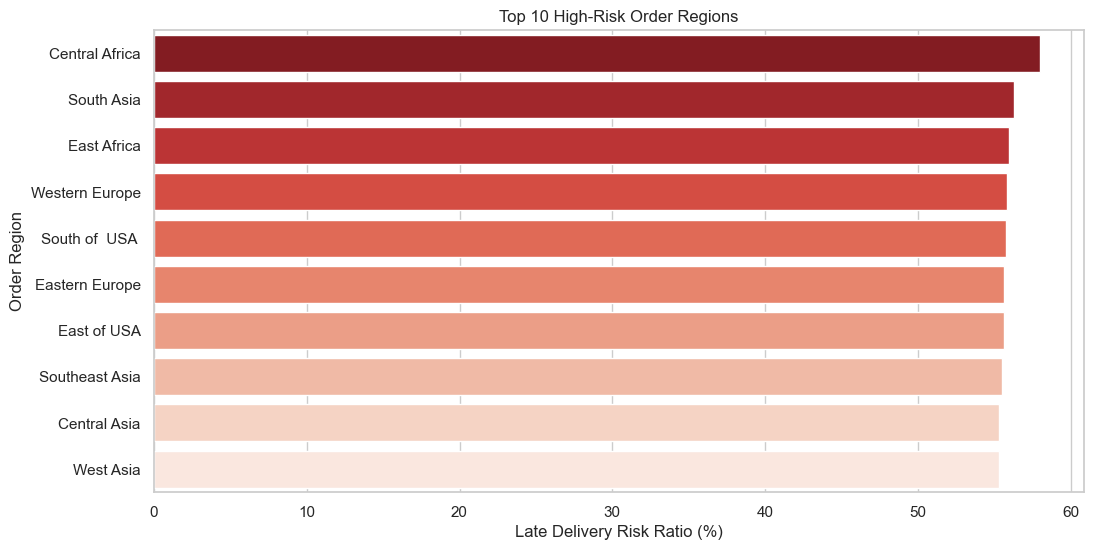

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=regional_analysis.head(10),
    x="Late_Risk_Ratio",
    y="Order Region",
    palette="Reds_r"
)

plt.title("Top 10 High-Risk Order Regions")
plt.xlabel("Late Delivery Risk Ratio (%)")
plt.ylabel("Order Region")
plt.show()


In [23]:
market_analysis = df_analysis.groupby("Market").agg(
    Total_Orders=("Market", "count"),
    Average_Delay_Gap=("Delivery Delay Gap", "mean"),
    Late_Risk_Ratio=("Late_delivery_risk", "mean")
).reset_index()

market_analysis["Late_Risk_Ratio"] *= 100

market_analysis = market_analysis.sort_values(by="Late_Risk_Ratio", ascending=False)

market_analysis


,Market,Total_Orders,Average_Delay_Gap,Late_Risk_Ratio
1,Europe,50252,0.570843,55.207753
3,Pacific Asia,41260,0.569365,55.046049
4,USCA,25799,0.568859,54.800574
0,Africa,11614,0.560014,54.589289
2,LATAM,51594,0.557836,54.355158


C:\Users\War Machine\AppData\Local\Temp\ipykernel_11524\332837588.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


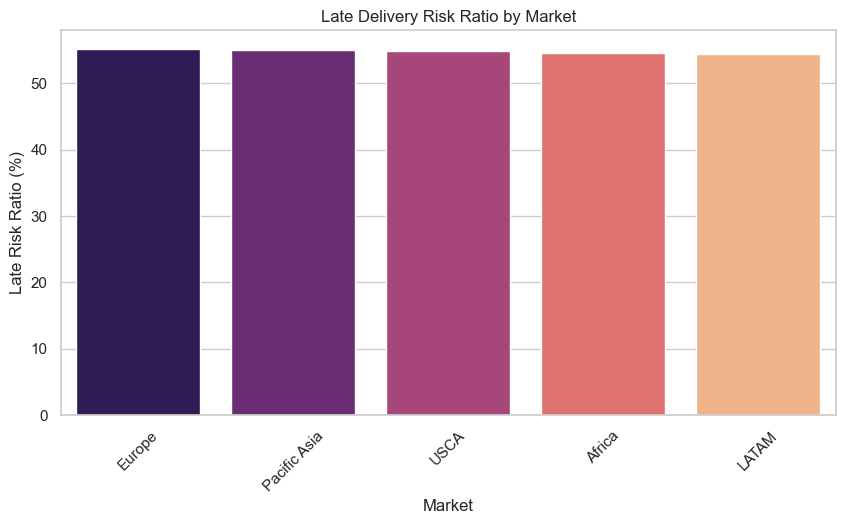

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=market_analysis,
    x="Market",
    y="Late_Risk_Ratio",
    palette="magma"
)

plt.title("Late Delivery Risk Ratio by Market")
plt.xlabel("Market")
plt.ylabel("Late Risk Ratio (%)")
plt.xticks(rotation=45)
plt.show()


In [25]:
country_analysis = df_analysis.groupby("Order Country").agg(
    Total_Orders=("Order Country", "count"),
    Average_Delay_Gap=("Delivery Delay Gap", "mean"),
    Late_Risk_Ratio=("Late_delivery_risk", "mean")
).reset_index()

country_analysis["Late_Risk_Ratio"] *= 100

country_analysis = country_analysis.sort_values(by="Late_Risk_Ratio", ascending=False)

country_analysis.head(10)


,Order Country,Total_Orders,Average_Delay_Gap,Late_Risk_Ratio
24,Bután,5,2.000000,100.0
7,Armenia,5,1.000000,100.0
62,Guinea Ecuatorial,2,1.500000,100.0
44,Eritrea,2,2.000000,100.0
125,República de Gambia,5,2.000000,100.0
144,Sáhara Occidental,2,2.000000,100.0
140,Sudán del Sur,5,2.200000,100.0
137,Suazilandia,5,2.000000,100.0
83,Laos,6,1.833333,100.0
88,Luxemburgo,10,2.700000,100.0


In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=segment_analysis,
    x="Customer Segment",
    y="Late_Risk_Ratio",
    palette="Blues"
)

plt.title("Late Delivery Risk by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Late Risk Ratio (%)")
plt.show()


NameError: name 'segment_analysis' is not defined

<Figure size 800x500 with 0 Axes>

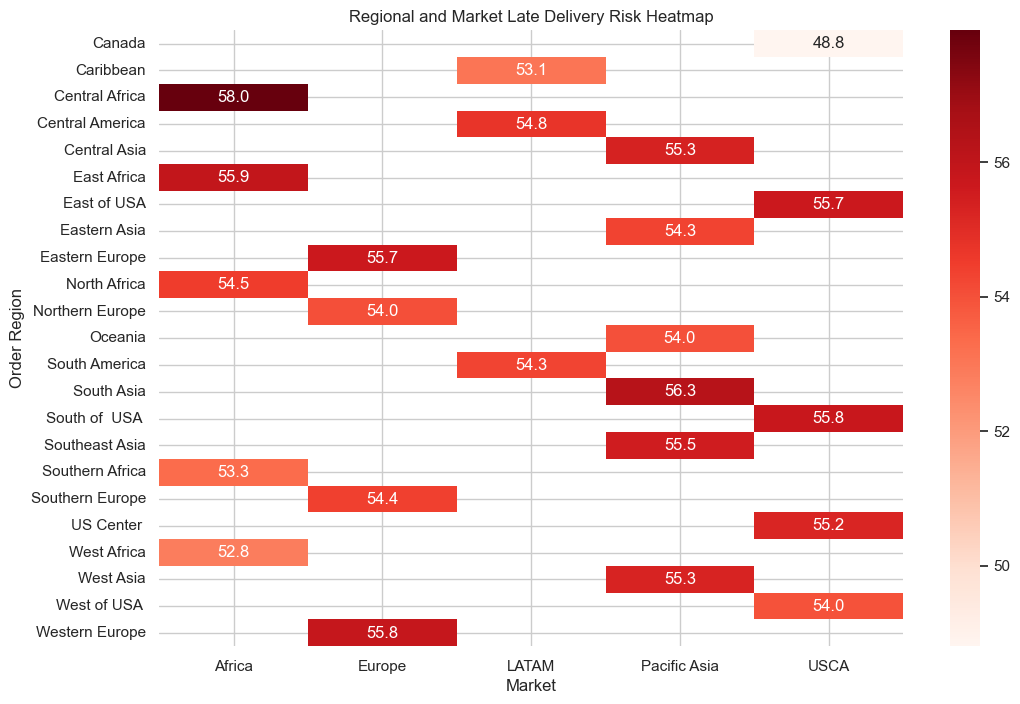

In [34]:
heatmap_data = df_analysis.pivot_table(
    index="Order Region",
    columns="Market",
    values="Late_delivery_risk",
    aggfunc="mean"
) * 100

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Regional and Market Late Delivery Risk Heatmap")
plt.xlabel("Market")
plt.ylabel("Order Region")
plt.show()


In [35]:
shipping_mode_analysis["Shipping Mode Efficiency Index"] = (
    100 - shipping_mode_analysis["Late_Risk_Ratio"]
)

shipping_mode_analysis.sort_values(
    by="Shipping Mode Efficiency Index",
    ascending=False
)


,Shipping Mode,Total_Orders,Average_Delay_Gap,Late_Risk_Ratio,Shipping Mode Efficiency Index
3,Standard Class,107752,-0.004093,38.071683,61.928317
1,Same Day,9737,0.478279,45.743042,54.256958
2,Second Class,35216,1.990828,76.632781,23.367219
0,First Class,27814,1.000000,95.322499,4.677501


In [36]:
regional_analysis["Regional Delay Index"] = (
    regional_analysis["Average_Delay_Gap"] * regional_analysis["Late_Risk_Ratio"]
)

regional_analysis.sort_values(
    by="Regional Delay Index",
    ascending=False
).head(10)


,Order Region,Total_Orders,Average_Delay_Gap,Late_Risk_Ratio,Regional Delay Index
2,Central Africa,1677,0.639833,57.960644,37.085135
4,Central Asia,553,0.645570,55.334539,35.722297
13,South Asia,7731,0.597465,56.266977,33.617536
22,Western Europe,27109,0.597403,55.848611,33.364132
6,East of USA,6915,0.584816,55.661605,32.551776
18,US Center,5887,0.587226,55.240360,32.438581
14,South of USA,4045,0.579975,55.772559,32.346705
8,Eastern Europe,3920,0.579847,55.663265,32.276174
5,East Africa,1852,0.570734,55.939525,31.926608
20,West Asia,6009,0.569479,55.283741,31.482936


In [37]:
worst_shipping_mode = shipping_mode_analysis.sort_values(
    by="Late_Risk_Ratio",
    ascending=False
).iloc[0]

worst_region = regional_analysis.sort_values(
    by="Late_Risk_Ratio",
    ascending=False
).iloc[0]

worst_market = market_analysis.sort_values(
    by="Late_Risk_Ratio",
    ascending=False
).iloc[0]

print("Key Insights")
print("------------")
print("Worst Shipping Mode:", worst_shipping_mode["Shipping Mode"])
print("Shipping Mode Late Risk (%):", round(worst_shipping_mode["Late_Risk_Ratio"], 2))

print("Highest Risk Region:", worst_region["Order Region"])
print("Region Late Risk (%):", round(worst_region["Late_Risk_Ratio"], 2))

print("Highest Risk Market:", worst_market["Market"])
print("Market Late Risk (%):", round(worst_market["Late_Risk_Ratio"], 2))


Key Insights
------------
Worst Shipping Mode: First Class
Shipping Mode Late Risk (%): 95.32
Highest Risk Region: Central Africa
Region Late Risk (%): 57.96
Highest Risk Market: Europe
Market Late Risk (%): 55.21


In [40]:
print("Recommendations")
print("---------------")
print("1. Focus on shipping modes with the highest late delivery risk.")
print("2. Investigate high-risk regions and markets for operational bottlenecks.")
print("3. Monitor shipments where actual shipping days exceed scheduled days.")
print("4. Improve planning for routes with repeated delay gaps.")
print("5. Prioritize customer segments affected by high delay risk.")
print("6. Use late_delivery_risk as an early warning indicator for SLA violations.")


Recommendations
---------------
1. Focus on shipping modes with the highest late delivery risk.
2. Investigate high-risk regions and markets for operational bottlenecks.
3. Monitor shipments where actual shipping days exceed scheduled days.
4. Improve planning for routes with repeated delay gaps.
5. Prioritize customer segments affected by high delay risk.
6. Use late_delivery_risk as an early warning indicator for SLA violations.
